## Importacion de librerias y de dataset

In [6]:
# Celda 1: Importaciones y Configuración de Datos
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image

# Configurar el dispositivo (GPU si está disponible, de lo contrario CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

# Transformaciones: Convertir PIL.Image a Tensor y normalizar
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Cargar datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Clases de CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Utilizando dispositivo: cpu


## Definicion de red neuronal convolucional

- Clasificar imagenes multi-clase

In [7]:
# Celda 2: CNN Básica
class CNNBasica(nn.Module):
    def __init__(self):
        super(CNNBasica, self).__init__()
        # Entrada: 3 canales. Salida: 16 canales. Spatial: 32x32
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Reduce a la mitad: 16x16 -> 8x8
        # Entrada: 16 canales. Salida: 32 canales. Spatial: 16x16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Aplanado: 32 canales * 8 alto * 8 ancho = 2048
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # Aplanar todas las dimensiones excepto el batch
        x = self.relu(self.fc1(x))
        x = self.fc2(x) # Sin activación final, la función de pérdida lo maneja
        return x

In [8]:
# Celda 3: CNN Intermedia con Dropout
class CNNIntermedia(nn.Module):
    def __init__(self):
        super(CNNIntermedia, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # Tras 3 capas de pooling, la dimensión espacial 32x32 se reduce a 4x4
        # 128 canales * 4 * 4 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [9]:
# Celda 4: CNN Profunda Estilo Bloques
class CNNProfunda(nn.Module):
    def __init__(self):
        super(CNNProfunda, self).__init__()
        # Bloque 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        # Bloque 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # Dos poolings: 32 -> 16 -> 8. Quedan mapas de 8x8 con 64 canales.
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.dropout(x)
        
        x = self.relu(self.conv3(x))
        x = self.pool(self.relu(self.conv4(x)))
        x = self.dropout(x)
        
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

## Loop de entrenamiento

- Epoca corresponde a iteracion completa
- En cada epoca el dataset se procesa en mini batches
- Los pesos se actualizaran
- Despues de cada epoca, calcular la perdida
- Desplegar curvas de aprendizaje 

In [10]:
# Celda 5: Definición del ciclo de entrenamiento universal
def entrenar_modelo(modelo, nombre_modelo, num_epochs=10, learning_rate=0.001):
    modelo = modelo.to(device)
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=learning_rate)
    
    historial_train_loss = []
    historial_test_loss = []
    
    print(f"--- Iniciando entrenamiento de {nombre_modelo} ---")
    for epoch in range(num_epochs):
        # Modo entrenamiento
        modelo.train()
        running_loss = 0.0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 1. Reiniciar gradientes (si no, se acumulan iteración a iteración)
            optimizador.zero_grad()
            
            # 2. Forward pass (propagación hacia adelante)
            outputs = modelo(inputs)
            
            # 3. Calcular pérdida
            loss = criterio(outputs, labels)
            
            # 4. Backward pass (retropropagación de errores)
            loss.backward()
            
            # 5. Actualizar pesos
            optimizador.step()
            
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(trainloader)
        historial_train_loss.append(avg_train_loss)
        
        # Modo evaluación
        modelo.eval()
        test_loss = 0.0
        with torch.no_grad(): # Desactivar tracking de gradientes
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = modelo(inputs)
                loss = criterio(outputs, labels)
                test_loss += loss.item()
                
        avg_test_loss = test_loss / len(testloader)
        historial_test_loss.append(avg_test_loss)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
        
    return historial_train_loss, historial_test_loss, modelo

## 3 Redes Neuronales Diferentes

## Eleccion del mejor modelo obtenido

--- Iniciando entrenamiento de CNN Básica ---
Epoch [1/15] | Train Loss: 1.4432 | Test Loss: 1.1904
Epoch [2/15] | Train Loss: 1.0975 | Test Loss: 1.0335
Epoch [3/15] | Train Loss: 0.9459 | Test Loss: 0.9555
Epoch [4/15] | Train Loss: 0.8507 | Test Loss: 0.9328
Epoch [5/15] | Train Loss: 0.7723 | Test Loss: 0.9337
Epoch [6/15] | Train Loss: 0.7075 | Test Loss: 0.8920
Epoch [7/15] | Train Loss: 0.6493 | Test Loss: 0.8906
Epoch [8/15] | Train Loss: 0.5864 | Test Loss: 0.9153
Epoch [9/15] | Train Loss: 0.5403 | Test Loss: 0.9488
Epoch [10/15] | Train Loss: 0.4910 | Test Loss: 0.9369
Epoch [11/15] | Train Loss: 0.4428 | Test Loss: 1.0086
Epoch [12/15] | Train Loss: 0.3971 | Test Loss: 1.0704
Epoch [13/15] | Train Loss: 0.3591 | Test Loss: 1.1371
Epoch [14/15] | Train Loss: 0.3155 | Test Loss: 1.1945
Epoch [15/15] | Train Loss: 0.2819 | Test Loss: 1.2624
--- Iniciando entrenamiento de CNN Intermedia ---
Epoch [1/15] | Train Loss: 1.4912 | Test Loss: 1.1432
Epoch [2/15] | Train Loss: 1.0718 

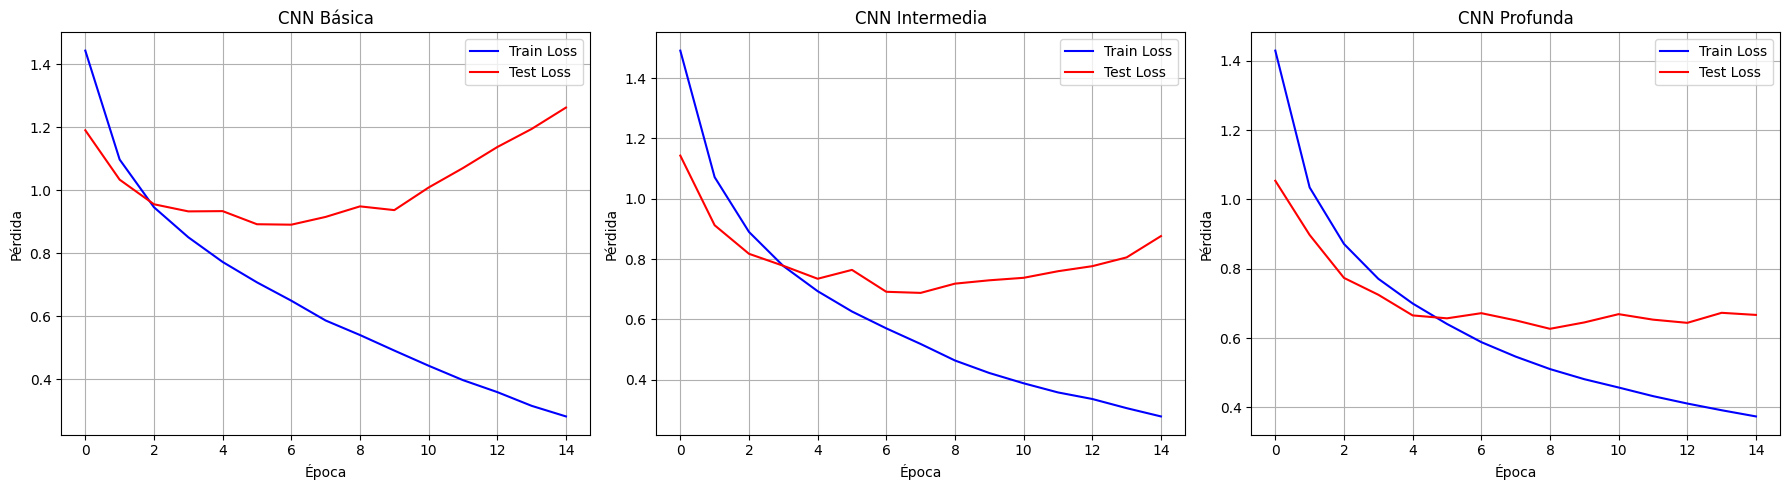

In [11]:
# Celda 6: Ejecución y Gráficas
epocas = 15

# Instanciar y entrenar
modelo1 = CNNBasica()
train_loss_1, test_loss_1, mod1_entrenado = entrenar_modelo(modelo1, "CNN Básica", num_epochs=epocas)

modelo2 = CNNIntermedia()
train_loss_2, test_loss_2, mod2_entrenado = entrenar_modelo(modelo2, "CNN Intermedia", num_epochs=epocas)

modelo3 = CNNProfunda()
train_loss_3, test_loss_3, mod3_entrenado = entrenar_modelo(modelo3, "CNN Profunda", num_epochs=epocas)

# Graficar
plt.figure(figsize=(18, 5))

modelos_loss = [
    ("CNN Básica", train_loss_1, test_loss_1),
    ("CNN Intermedia", train_loss_2, test_loss_2),
    ("CNN Profunda", train_loss_3, test_loss_3)
]

for i, (nombre, t_loss, v_loss) in enumerate(modelos_loss):
    plt.subplot(1, 3, i+1)
    plt.plot(t_loss, label='Train Loss', color='blue')
    plt.plot(v_loss, label='Test Loss', color='red')
    plt.title(nombre)
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Celda 7: Evaluación de Accuracy
def calcular_accuracy(modelo, dataloader):
    modelo.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = modelo(inputs)
            # La clase predicha es el índice con el mayor valor de activación
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return 100 * correct / total

mejor_modelo = mod3_entrenado # Asumimos la CNN Profunda, ajústalo según tus resultados
accuracy_test = calcular_accuracy(mejor_modelo, testloader)
print(f"Accuracy del Mejor Modelo en el conjunto de Test: {accuracy_test:.2f}%")

Accuracy del Mejor Modelo en el conjunto de Test: 78.53%


## Clasificar imagenes arbitrarias 
- Son proporcionadas por el usuario
- Recibir la ruta en disco la imagen a clasificar y regresar etiqueta
- Modelo a utilizar el mejor de los 3

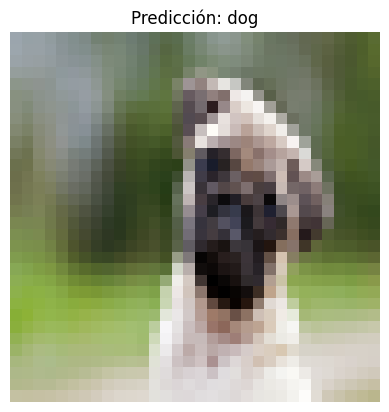

La imagen fue clasificada como: dog


In [ ]:

def predecir_imagen(ruta_imagen, modelo, transformacion, clases):
    try:
        # Abrir imagen y forzar formato RGB (evita problemas con imágenes RGBA/Grises)
        
        img = Image.open(ruta_imagen).convert('RGB')
        
        # Redimensionar explícitamente a 32x32 antes de transformar
        img = img.resize((32, 32))
        
        # Aplicar el mismo transform usado en DataLoader
        img_tensor = transformacion(img)
        
        # Agregar la dimensión del batch: (C, H, W) -> (1, C, H, W)
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        modelo.eval()
        with torch.no_grad():
            salida = modelo(img_tensor)
            _, indice_predicho = torch.max(salida, 1)
            
        clase_predicha = clases[indice_predicho.item()]
        
        # Mostrar la imagen junto a la predicción
        plt.imshow(img)
        plt.title(f"Predicción: {clase_predicha}")
        plt.axis('off')
        plt.show()
        
        return clase_predicha
    except Exception as e:
        return f"Error procesando la imagen: {e}"

# ---------------------------------------------------------
# 2. EJECUCIÓN 
#


ruta_prueba = r"C:\Users\mario\OneDrive\Desktop\Codigos\Inteligencia-Computacional\Inteligencia-Computacional\Redes-Convolucionales-Pytorch\perro.jpg"


etiqueta = predecir_imagen(ruta_imagen=ruta_prueba, 
                           modelo=mejor_modelo, 
                           transformacion=transform, 
                           clases=classes)

print(f"La imagen fue clasificada como: {etiqueta}")

## Conclusiones